In [ ]:
Variables in order:
 CRIM     per capita crime rate by town
 ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
 INDUS    proportion of non-retail business acres per town
 CHAS     Charles River dummy variable (= 1 if tract bounds river; 0 otherwise)
 NOX      nitric oxides concentration (parts per 10 million)
 RM       average number of rooms per dwelling
 AGE      proportion of owner-occupied units built prior to 1940
 DIS      weighted distances to five Boston employment centres
 RAD      index of accessibility to radial highways
 TAX      full-value property-tax rate per $10,000
 PTRATIO  pupil-teacher ratio by town
 B        1000(Bk - 0.63)^2 where Bk is the proportion of blacks by town
 LSTAT    % lower status of the population
 MEDV     Median value of owner-occupied homes in $1000's

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [15]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
C:\Users\hulaw\AppData\Local\Temp\ipykernel_10860\16828617.py:2: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [19]:
import pandas as pd

df_boston = pd.DataFrame(
    data,
    columns=['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM',
             'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']
)

df_boston['PRICE'] = target

In [21]:
df_boston

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,PRICE
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48,22.0


In [25]:
df_boston.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
PRICE      0
dtype: int64

In [27]:
df.shape

(506, 14)

In [29]:
df.columns

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [33]:
x=df_boston.drop('PRICE',axis=1) # multiple linear regression # Methos 1

In [ ]:
# another way of taking dependent variable if and only if the dataset hav=ing its target column in the last
x=df_boston.iloc[:,:-1] # Method 2

In [35]:
y=df_boston['PRICE']
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: PRICE, Length: 506, dtype: float64

In [ ]:
MODEL BUILDING

In [41]:
xc=sm.add_constant(x)
ols_model=sm.OLS(y,xc).fit()
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  PRICE   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     108.1
Date:                Tue, 24 Mar 2026   Prob (F-statistic):          6.72e-135
Time:                        18:29:18   Log-Likelihood:                -1498.8
No. Observations:                 506   AIC:                             3026.
Df Residuals:                     492   BIC:                             3085.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.4595      5.103      7.144      0.000      26.432      46.487
CRIM          -0.1080      0.033     -3.287      0.001      -0.173      -0.043
ZN             0.0464      0.014      3.382      0.001       0.019       0.073
INDUS          0.0206      0.061      0.334      0.738      -0.100       0.141
CHAS           2.6867      0.862      3.118      0.002       0.994       4.380
NOX          -17.7666      3.820     -4.651      0.000     -25.272     -10.262
RM             3.8099      0.418      9.116      0.000       2.989       4.631
AGE            0.0007      0.013      0.052      0.958      -0.025       0.027
DIS           -1.4756      0.199     -7.398      0.000      -1.867      -1.084
RAD            0.3060      0.066      4.613      0.000       0.176       0.436
TAX           -0.0123      0.004     -3.280      0.001      -0.020      -0.005
PTRATIO       -0.9527      0.131     -7.283      0.000      -1.210      -0.696
B              0.0093      0.003      3.467      0.001       0.004       0.015
LSTAT         -0.5248      0.051    -10.347      0.000      -0.624      -0.425
==============================================================================
Omnibus:                      178.041   Durbin-Watson:                   1.078
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              783.126
Skew:                           1.521   Prob(JB):                    8.84e-171
Kurtosis:                       8.281   Cond. No.                     1.51e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.51e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [43]:
y_pred=ols_model.fittedvalues
residuals=ols_model.resid
y_pred

0      30.003843
1      25.025562
2      30.567597
3      28.607036
4      27.943524
         ...    
501    23.533341
502    22.375719
503    27.627426
504    26.127967
505    22.344212
Length: 506, dtype: float64

In [ ]:
ASSUMPTION 1 : NO MULTICOLLINEARITY

VIF -- measure the correlation between independent values

In [45]:
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF

In [47]:
xc.columns

Index(['const', 'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS',
       'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'],
      dtype='object')

In [49]:
VIF(xc.values,1) # It gives values for 1st column as target variable then others are predicted variables

1.7921915474332406

In [51]:
VIF(xc.values,2) 

2.2987581787494418

In [53]:
vif_values= [ VIF(xc.values, 1) for i in range(xc.shape[1])]
DF1= pd.DataFrame(vif_values, columns = ['VIF Value'], index = xc.columns).sort_values('VIF Value', ascending = False)

In [55]:
DF1

,VIF Value
const,1.792192
CRIM,1.792192
ZN,1.792192
INDUS,1.792192
CHAS,1.792192
NOX,1.792192
RM,1.792192
AGE,1.792192
DIS,1.792192
RAD,1.792192


In [ ]:
# due to multicolinearity remove tax column

In [57]:
x=df_boston.drop(['TAX'],axis=1)
xc=sm.add_constant(x)

In [59]:
xc

,const,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,PTRATIO,B,LSTAT,PRICE
0,1.0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,15.3,396.90,4.98,24.0
1,1.0,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,17.8,396.90,9.14,21.6
2,1.0,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,17.8,392.83,4.03,34.7
3,1.0,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,18.7,394.63,2.94,33.4
4,1.0,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,1.0,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,21.0,391.99,9.67,22.4
502,1.0,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,21.0,396.90,9.08,20.6
503,1.0,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,21.0,396.90,5.64,23.9
504,1.0,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,21.0,393.45,6.48,22.0


In [61]:
vif_values= [ VIF(xc.values, 1) for i in range(xc.shape[1])]
DF1= pd.DataFrame(vif_values, columns = ['VIF Value'], index = xc.columns).sort_values('VIF Value', ascending = False)

In [63]:
DF1

,VIF Value
const,1.829538
CRIM,1.829538
ZN,1.829538
INDUS,1.829538
CHAS,1.829538
NOX,1.829538
RM,1.829538
AGE,1.829538
DIS,1.829538
RAD,1.829538


In [ ]:
MODEL BUILDING

In [65]:
ols_model=sm.OLS(y,xc).fit()
ols_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  PRICE   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 9.900e+30
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:50:27   Log-Likelihood:                 15297.
No. Observations:                 506   AIC:                        -3.057e+04
Df Residuals:                     492   BIC:                        -3.051e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.842e-14   2.04e-14      1.396      0.163   -1.16e-14    6.84e-14
CRIM       -2.394e-16   1.27e-16     -1.878      0.061    -4.9e-16    1.11e-17
ZN          1.388e-17   5.18e-17      0.268      0.789   -8.78e-17    1.16e-16
INDUS       6.939e-17   2.13e-16      0.326      0.744   -3.48e-16    4.87e-16
CHAS       -3.331e-15   3.32e-15     -1.002      0.317   -9.86e-15     3.2e-15
NOX         5.773e-15    1.5e-14      0.386      0.700   -2.36e-14    3.52e-14
RM          2.442e-15   1.73e-15      1.408      0.160   -9.66e-16    5.85e-15
AGE        -2.082e-16   5.07e-17     -4.106      0.000   -3.08e-16   -1.09e-16
DIS        -2.331e-15   8.07e-16     -2.889      0.004   -3.92e-15   -7.46e-16
RAD        -1.162e-16   1.59e-16     -0.733      0.464   -4.28e-16    1.95e-16
PTRATIO    -4.163e-17   5.28e-16     -0.079      0.937   -1.08e-15    9.97e-16
B           7.112e-17   1.04e-17      6.814      0.000    5.06e-17    9.16e-17
LSTAT      -5.412e-16   2.14e-16     -2.526      0.012   -9.62e-16    -1.2e-16
PRICE          1.0000   1.71e-16   5.84e+15      0.000       1.000       1.000
==============================================================================
Omnibus:                      106.408   Durbin-Watson:                   0.191
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              187.429
Skew:                           1.232   Prob(JB):                     2.00e-41
Kurtosis:                       4.679   Cond. No.                     1.06e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.06e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
ASSUMPTIONS AFTER MODEL BULIDING

In [67]:
y_pred=ols_model.fittedvalues
residuals=ols_model.resid

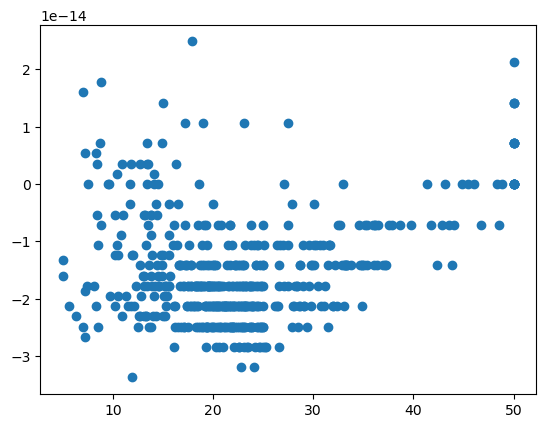

In [69]:
plt.scatter(y_pred,residuals)

In [ ]:
1. LINEAR RELATIONSHIP BETWEEN DEPENDENT AND INDEPENDENT VARIABLES

In [77]:
# to test linearity
from statsmodels.stats.api import linear_rainbow
test_stat,p_value=linear_rainbow(ols_model)

In [79]:
test_stat,p_value

(-0.6735893735269363, 1.0)

In [ ]:
AFTER MODEL BUILDING TEST 

In [ ]:
2. INDEPENDENCE OF OBSERVATIONS SHOULD EXIST (THAT IS ABSENCE OF AUTOCORRELATION)

In [83]:
from statsmodels.stats.stattools import durbin_watson

In [89]:
durbin_watson(residuals)

0.19109818659607564

In [ ]:
1. limits are '0 to 2' positive autocorrelation
2. limits are equale to 2 No autocorrelation
3. limits are equale to 2 to 4 Negative correlation

positive autocorrelation --  because of exisiting residuals increasing.
negative autocorrelation --  because of exisiting residuals decreasing.

In [ ]:
ASSUMPTION 4 : HOMOSCEDASTICITY (NO HETEROSCEDASTICITY)

In [ ]:
VARIANCE AMONG RESIDUALS EQUALE

In [91]:
from statsmodels.stats.api import het_breuschpagan

In [93]:
het_breuschpagan(residuals,xc)[2:]

(109.30371188683215, 8.706004942267855e-136)

In [ ]:
ASSUMPTION 5 : NORMALITY TEST

In [ ]:
NORMALITY OF RESIDUALS


In [95]:
import scipy.stats as stats

In [97]:
stats.shapiro(residuals)

ShapiroResult(statistic=0.9016534604200839, pvalue=1.5670583149780057e-17)

In [99]:
from statsmodels.api import qqplot

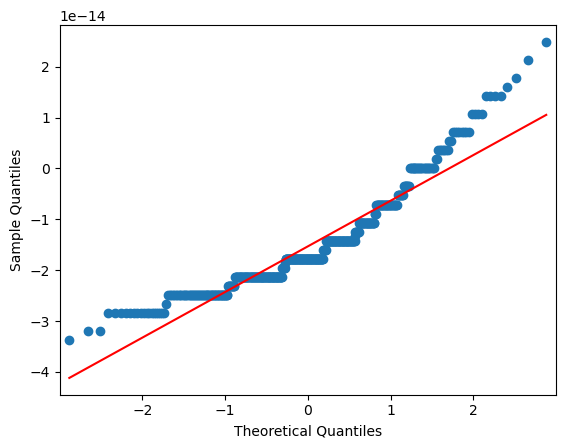

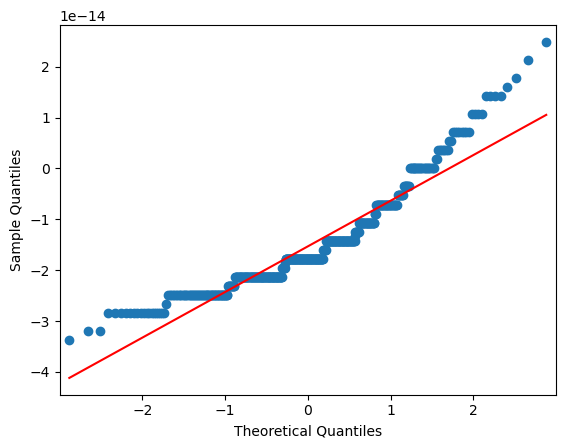

In [101]:
qqplot(residuals,line='r')

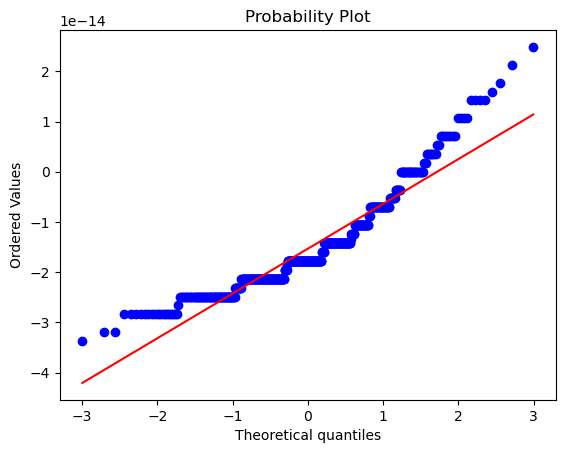

In [103]:
stats.probplot(residuals,plot=plt)
plt.show()

In [ ]:
# WAP number is prime or not

Number=int(input('Enter the number: '))
if Number>1:
    for i in range

In [107]:
Number = int(input("Enter the number: "))

if Number <= 1:
    print("Not Prime")
else:
    for i in range(2, Number):
        if Number % i == 0:
            print("Not Prime")
            break
    else:
        print("Prime")

Enter the number:  52


Not Prime
